In [15]:
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
from torch.optim import AdamW
from torchmetrics import F1Score

In [16]:
seed = 42
torch.random.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32

root_path = "/home/stefan/ioai-prep/kits/bcs/pictures"

# Data

In [17]:
class ImageDataset(Dataset):
    def __init__(self, is_train: bool, label_encoder: LabelEncoder | None = None):
        super().__init__()

        self.dir = f"{root_path}/train" if is_train else f"{root_path}/test"
        self.df = pd.read_csv("train_data.csv" if is_train else "test_data.csv")
        self.is_train = is_train

        if is_train:
            self.lb = LabelEncoder()
            self.targets = self.lb.fit_transform(self.df["label"])

            self.transforms = T.Compose([
                T.Resize((224, 224)),
                T.RandomHorizontalFlip(),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            # reuse encoder from train
            self.lb = label_encoder

            self.transforms = T.Compose([
                T.Resize((224, 224)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filepath = f"{self.dir}/{row['ID']}.jpg"

        img = Image.open(filepath).convert("RGB")
        img = self.transforms(img)

        if "label" in self.df.columns:
            label = self.lb.transform([row["label"]])
            label = torch.tensor(label, dtype=torch.long)
            return img, label
        
        return img
    
    def __len__(self):
        return len(self.df) // 1

In [18]:
full_train_ds = ImageDataset(is_train=True)
lb = full_train_ds.lb

train_ds, val_ds = random_split(full_train_ds, [0.8, 0.2])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

test_ds = ImageDataset(is_train=False, label_encoder=lb)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [ ]:
# sanity check
batch = next(iter(train_loader))
print([v.shape for v in batch])

[torch.Size([32, 3, 224, 224]), torch.Size([32, 1])]


# Model

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes: int = 6):
        super().__init__()
        self.num_classes = num_classes

        self.block1 = self._make_block(3, 16)
        self.block2 = self._make_block(16, 32)
        self.block3 = self._make_block(32, 64)
        self.block4 = self._make_block(64, 128)

        self.fc1 = nn.Linear(128 * 14 * 14, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def _make_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        
        x = self.drop(x)
        return self.fc2(x)

In [21]:
model = CNN().to(device)

x = batch[0].to(device)
model(x).shape

torch.Size([32, 6])

# Training

In [ ]:
epochs = 15

learning_rate = 4e-3

In [25]:
optim = AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
f1_macro = F1Score(task="multiclass", num_classes=6, average='macro').to(device)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, eta_min=1e-5, T_max=epochs)
scaler = torch.amp.grad_scaler.GradScaler(device)

In [ ]:
metrics_history = {
  'train_loss': [],
  'train_f1_macro': [],
  'test_loss': [],
  'test_f1_macro': [],
}

def plot_metrics(metrics_history, epoch):
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title('Loss')
    ax2.set_title('F1 Macro')
    for dataset in ('train', 'test'):
      ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}', marker=".")
      ax2.plot(metrics_history[f'{dataset}_f1_macro'], label=f'{dataset}', marker=".")
    ax1.legend()
    ax2.legend()
    plt.show()

    print(f"Epoch {epoch}:")
    print(pd.DataFrame(metrics_history, index=None).tail(5))
    print("----------------------------")

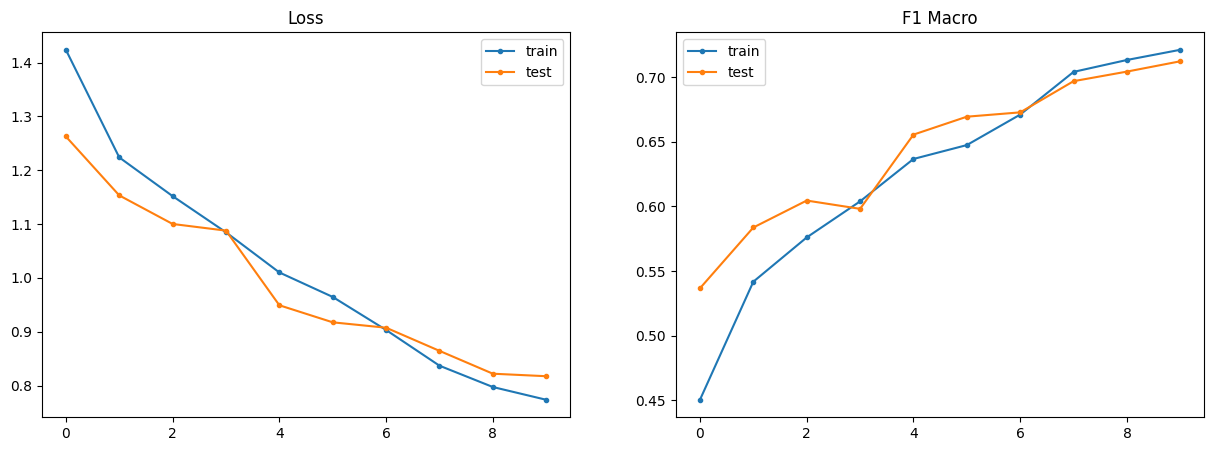

Epoch 10:
   train_loss  train_f1_macro  test_loss  test_f1_macro
5    0.964723        0.647497   0.917579       0.669461
6    0.903338        0.671100   0.907575       0.672813
7    0.837047        0.704132   0.864597       0.696947
8    0.797476        0.713349   0.822185       0.704354
9    0.773781        0.721238   0.817541       0.712341
----------------------------


In [ ]:
for epoch in range(1, epochs+1):
  # 1. train
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(train_loader):
    images, labels = images.to(device), labels.to(device).squeeze()

    # forward pass
    with torch.amp.autocast(device):
      logits = model(images)
      loss = criterion(logits, labels)

    # backward pass
    optim.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optim)
    scaler.update()

    running_loss += loss.item()
    f1_macro.update(logits, labels)
  scheduler.step()
    
  metrics_history["train_loss"].append(running_loss / len(train_loader))
  metrics_history["train_f1_macro"].append(f1_macro.compute().detach().cpu().item())
  running_loss = 0.0
  f1_macro.reset()

  # 1. evaluation
  model.eval()
  for images, labels in tqdm(val_loader):
    images, labels = images.to(device), labels.to(device).squeeze()

    with torch.no_grad():
      logits = model(images)
      loss = criterion(logits, labels)

    running_loss += loss.item()
    f1_macro.update(logits, labels)

  metrics_history["test_loss"].append(running_loss / len(val_loader))
  metrics_history["test_f1_macro"].append(f1_macro.compute().detach().cpu().item())
  f1_macro.reset()

  plot_metrics(metrics_history, epoch)

# Submission

In [27]:
labels = []

for images in tqdm(test_loader):
    with torch.no_grad():
        logits = model(images.to(device))
    
    label = torch.argmax(logits, dim=-1).detach().cpu().tolist()
    label = lb.inverse_transform(label)
    
    labels.extend(label)

100%|██████████| 45/45 [00:03<00:00, 13.62it/s]


In [28]:
submission = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": test_ds.df["ID"],
    "answer": labels
})

In [29]:
submission.head()

,subtaskID,datapointID,answer
0,1,9281,glass
1,1,9282,paper
2,1,9283,trash
3,1,9284,glass
4,1,9285,glass


In [30]:
submission.to_csv("submission.csv", index=False)